In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 64s 6us/step
Training samples: (60000, 28, 28)
Test samples    : (10000, 28, 28)

Training the discriminative classifier...


c:\Documents\Tanvi\generative-ai-practicals\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8965 - loss: 0.3743 - val_accuracy: 0.9560 - val_loss: 0.1652
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9507 - loss: 0.1712 - val_accuracy: 0.9647 - val_loss: 0.1283
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9644 - loss: 0.1242 - val_accuracy: 0.9713 - val_loss: 0.0979

Classifier accuracy: 0.9659000039100647

Training the generative autoencoder...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0440 - val_loss: 0.0229
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0185 - val_loss: 0.0155
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0144 - val_loss: 0.0132

Reconstructing test images...
Reconstructed images shape: (5, 28, 28)


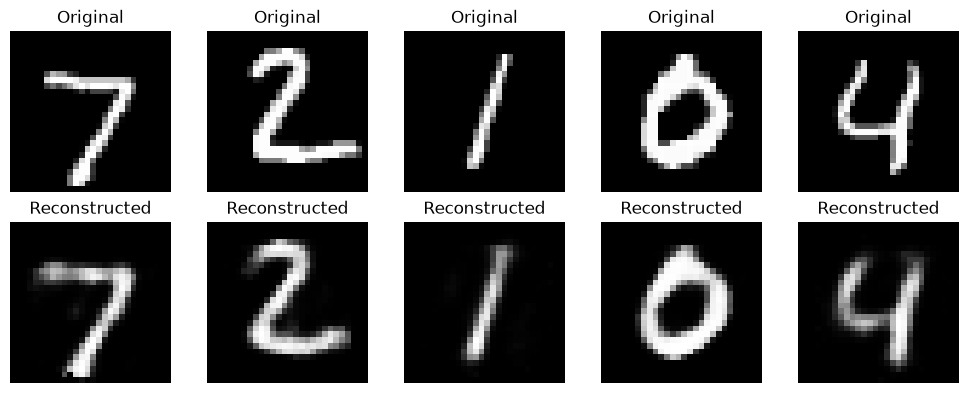


Observation:
The discriminative model classifies MNIST digits.
The generative autoencoder learns image representations
and reconstructs images similar to the original images.

Practical 1 completed successfully.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
# 1. Load and Normalize MNIST Dataset
print("Loading MNIST dataset...")

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training samples:", x_train.shape)
print("Test samples    :", x_test.shape)


# ============================================================
# 2. DISCRIMINATIVE MODEL - CLASSIFIER
# ============================================================

print("\nTraining the discriminative classifier...")

discriminator_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

discriminator_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

discriminator_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

loss, accuracy = discriminator_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nClassifier accuracy:", accuracy)


# ============================================================
# 3. GENERATIVE MODEL - AUTOENCODER
# ============================================================

print("\nTraining the generative autoencoder...")

generator_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(32, activation="relu"),
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid"),
    Reshape((28, 28))
])

generator_model.compile(
    optimizer="adam",
    loss="mse"
)

generator_model.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)


# ============================================================
# 4. RECONSTRUCT TEST IMAGES
# ============================================================

print("\nReconstructing test images...")

reconstructed_images = generator_model.predict(
    x_test[:5],
    verbose=0
)

print("Reconstructed images shape:", reconstructed_images.shape)


# ============================================================
# 5. VISUALIZE ORIGINAL VS RECONSTRUCTED
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(5):

    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstructed image
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()


# ============================================================
# OBSERVATION
# ============================================================

print("\nObservation:")
print("The discriminative model classifies MNIST digits.")
print("The generative autoencoder learns image representations")
print("and reconstructs images similar to the original images.")

print("\nPractical 1 completed successfully.")